<a href="https://colab.research.google.com/github/gabrielelim/Nairobi_pollution_monitoring_framework/blob/main/ozone_column_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#loas

In [94]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [17]:
os.chdir('/content/drive/MyDrive/gawdata/2024')
os.listdir()

['ecc_asap_data.parquet',
 'ecc_asap_metadata.parquet',
 '12',
 '10',
 '11',
 '09',
 '08',
 '07',
 '06',
 '04',
 '05',
 '01',
 '03',
 '02']

In [82]:
all_months = []
for n in os.listdir():
  if n.isdigit() and len(n)==2:
    file_path = os.path.join(n,'d018_nrb_data.parquet')
    print(file_path)
    df_month = pd.read_parquet(file_path)
    df_month['source'] = n
    df_month['dtm'] = pd.to_datetime(df_month['dtm'],errors='coerce')
    df_month.dropna(subset=['dtm'])
    df_month = df_month.set_index('dtm')
    all_months.append(df_month)
if all_months:
    df = pd.concat(all_months)
    #df['dtm'] = pd.to_datetime(df['dtm'])

    df = df.sort_index()
    df['XAD'] = pd.to_numeric(df['XAD'], errors='coerce')
    df['mu'] = pd.to_numeric(df['mu'], errors='coerce')
    #clean_df = df[(df['XAD'] > 0) & (df['mu'] < 3.5)]
    realistic_mask = (df['XAD'] > 150) & (df['XAD'] < 400) & (df['mu'] < 3.5)
    clean_df = df[realistic_mask].copy()
    #clean_df = df[(df['XAD'] > 0) & (df['XAD'] < 500) & (df['mu'] < 3.5)]








12/d018_nrb_data.parquet
10/d018_nrb_data.parquet
11/d018_nrb_data.parquet
09/d018_nrb_data.parquet
08/d018_nrb_data.parquet
07/d018_nrb_data.parquet
06/d018_nrb_data.parquet
04/d018_nrb_data.parquet
05/d018_nrb_data.parquet
01/d018_nrb_data.parquet
03/d018_nrb_data.parquet
02/d018_nrb_data.parquet


In [118]:
os.chdir('/content/drive/MyDrive/gawdata/2025')
base_path='/content/drive/MyDrive/gawdata/2025'
os.listdir()
folders = sorted(os.listdir(base_path))
isdigit = [f for f in folders if f.isdigit()]
file_path = os.path.join('12','avo-daily.parquet')
df= pd.read_parquet(file_path)

cols_of_interest = ['co2', 'pm25_conc', 'tp', 'hm', 'pr']

# Generate the statistics table
daily_stats = df[cols_of_interest].agg(['mean', 'std', 'min', 'max'])
print(daily_stats)
#len(isdigit[0])

             co2  pm25_conc         tp         hm            pr
mean  411.687256  15.850909  19.656366  75.590912  82175.710938
std     4.607324   3.195070   1.115507   6.508008     96.335442
min   403.899994   6.400000  16.600000  65.400002  81977.398438
max   427.200012  20.900000  22.299999  93.300003  82368.796875


In [109]:

all_months = []
for n in folders:
  if n.isdigit() and len(n)==2:
    file_path = os.path.join(n,'avo-daily.parquet')
    print(file_path)
    df_month = pd.read_parquet(file_path)
    df_month['source'] = n
    df_month['dtm'] = pd.to_datetime(df_month['dtm'],errors='coerce')
    df_month.dropna(subset=['dtm'])
    df_month = df_month.set_index('dtm')
    all_months.append(df_month)
if all_months:
    df = pd.concat(all_months)
    #df['dtm'] = pd.to_datetime(df['dtm'])

    df = df.sort_index()
    df['XAD'] = pd.to_numeric(df['XAD'], errors='coerce')
    df['mu'] = pd.to_numeric(df['mu'], errors='coerce')
    #clean_df = df[(df['XAD'] > 0) & (df['mu'] < 3.5)]
    realistic_mask = (df['XAD'] > 150) & (df['XAD'] < 400) & (df['mu'] < 3.5)
    clean_df = df[realistic_mask].copy()
    #clean_df = df[(df['XAD'] > 0) & (df['XAD'] < 500) & (df['mu'] < 3.5)]
    daily_stats = clean_df.resample('M')['XAD'].agg(['mean', 'std', 'min','max'])


top_5_ozone = clean_df.nlargest(5,columns=['XAD','mu'])

print("Top 5 Maximum Ozone Measurements (DU):")
#print(top_5_ozone)

#print("Daily Ozone Summary (DU):")
print(daily_stats)


01/avo-daily.parquet
02/avo-daily.parquet
03/avo-daily.parquet
04/avo-daily.parquet
05/avo-daily.parquet
06/avo-daily.parquet
07/avo-daily.parquet
08/avo-daily.parquet
09/avo-daily.parquet
10/avo-daily.parquet
11/avo-daily.parquet
12/avo-daily.parquet


KeyError: 'XAD'

In [16]:
# Replace 'your_file.parquet' with the actual file name in the 'gawdata' directory
parquet_file_path = glob.glob('d018*.parquet')[0]
print(parquet_file_path)
try:
    df = pd.read_parquet(parquet_file_path)
    print(f"Successfully loaded parquet file from {parquet_file_path}")
except FileNotFoundError:
    print(f"Error: The file '{parquet_file_path}' was not found. Please ensure the path is correct.")
    df = None
except Exception as e:
    print(f"An error occurred while loading the parquet file: {e}")
    df = None

d018_nrb_data.parquet
Successfully loaded parquet file from d018_nrb_data.parquet


### Data Overview

Let's take a look at the first 5 rows and the general information about the DataFrame to understand its structure and data types.

In [83]:
if df is not None:
    print("First 5 rows of the DataFrame:")
    display(df.tail())
    print("\nDataFrame Info:")
    df.info()

First 5 rows of the DataFrame:


,source,type,sequence,comments,sza,mu,XAD,XCD,X1,X2,X3,X4,X5,X6,X7
dtm,,,,,,,,,,,,,,,
2024-12-31 11:16:00+00:00,12,DS,ADADA,"4, 35, CB",32.6,1.185,251.0,,265.7,322.9,266.0,319.3,264.9,,
2024-12-31 12:12:00+00:00,12,DS,ADADA,"3, 40, CB",43.6,1.377,248.7,,257.1,291.5,257.6,291.8,258.1,,
2024-12-31 12:13:00+00:00,12,DS,ADADA,"3, 40, CB",43.8,1.382,249.8,,259.2,291.8,258.5,292.1,257.8,,
2024-12-31 12:14:00+00:00,12,DS,ADADA,"3, 40, CB",44.0,1.386,249.7,,259.3,294.3,258.6,288.2,257.1,,
2024-12-31 12:15:00+00:00,12,DS,ADADA,"3, 40, CB",44.3,1.391,248.9,,258.2,290.3,257.5,290.6,256.8,,



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3428 entries, 2024-01-02 06:25:00+00:00 to 2024-12-31 12:15:00+00:00
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   source    3428 non-null   object 
 1   type      3428 non-null   object 
 2   sequence  3428 non-null   object 
 3   comments  3428 non-null   object 
 4   sza       3428 non-null   object 
 5   mu        3428 non-null   float64
 6   XAD       3428 non-null   float64
 7   XCD       3428 non-null   object 
 8   X1        3428 non-null   object 
 9   X2        3428 non-null   object 
 10  X3        3428 non-null   object 
 11  X4        3428 non-null   object 
 12  X5        3428 non-null   object 
 13  X6        3428 non-null   object 
 14  X7        3428 non-null   object 
dtypes: float64(2), object(13)
memory usage: 428.5+ KB


In [88]:
#df['XAD'] = pd.to_numeric(df['XAD'], errors='coerce')
#df['mu'] = pd.to_numeric(df['mu'], errors='coerce')
#clean_df = df[(df['XAD'] > 0) & (df['mu'] < 3.5)].copy()

# 2. Calculate Daily Statistics
daily_stats = clean_df.resample('M')['XAD'].agg(['mean', 'std', 'min','max'])
top_5_ozone = clean_df.nlargest(5,columns=['XAD','mu'])

print("Top 5 Maximum Ozone Measurements (DU):")
#print(top_5_ozone)

#print("Daily Ozone Summary (DU):")
print(daily_stats)


Top 5 Maximum Ozone Measurements (DU):
                                 mean        std    min    max
dtm                                                           
2024-01-31 00:00:00+00:00  233.925993   7.761227  204.3  266.0
2024-02-29 00:00:00+00:00  236.097909   7.710845  197.9  250.9
2024-03-31 00:00:00+00:00  245.977700   8.575672  228.7  279.5
2024-04-30 00:00:00+00:00  245.024254  11.086455  228.5  319.8
2024-05-31 00:00:00+00:00  252.106230  14.352232  191.3  365.9
2024-06-30 00:00:00+00:00  264.730047   8.500979  244.8  312.3
2024-07-31 00:00:00+00:00  260.588393  11.699413  168.2  303.2
2024-08-31 00:00:00+00:00  258.260261  10.791684  213.7  303.2
2024-09-30 00:00:00+00:00  269.691981   8.848485  237.6  300.2
2024-10-31 00:00:00+00:00  269.004198  10.621511  236.9  300.4
2024-11-30 00:00:00+00:00  253.283871   8.793041  233.7  270.6
2024-12-31 00:00:00+00:00  250.327574   8.480932  233.8  309.8


/tmp/ipykernel_3287/2184340174.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  daily_stats = clean_df.resample('M')['XAD'].agg(['mean', 'std', 'min','max'])


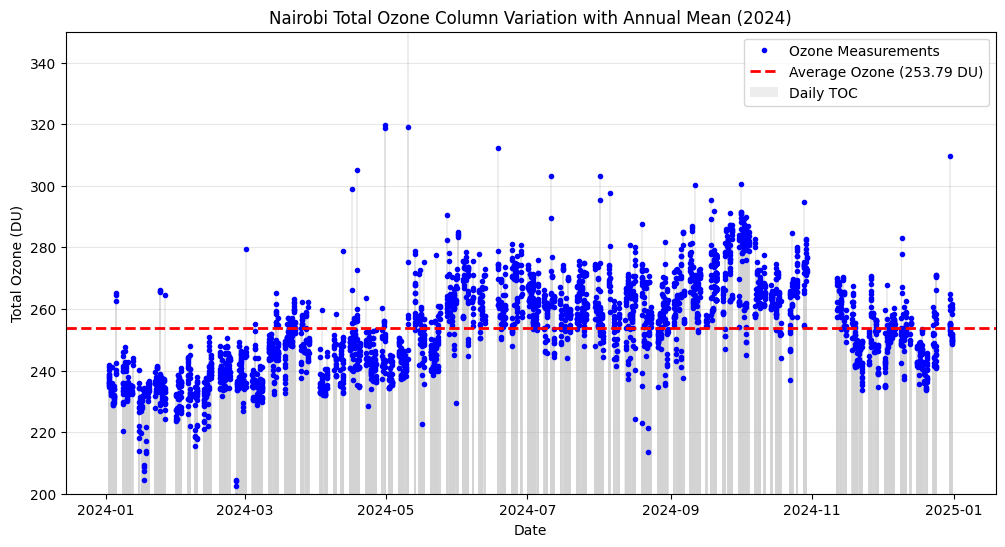

The calculated average for the period is: 253.79 DU


In [90]:
import matplotlib.pyplot as plt

# 1. Calculate the average of your cleaned XAD values
ozone_average = clean_df['XAD'].mean()

# 2. Setup the figure
plt.figure(figsize=(12, 6))

# 3. Plot Bar Chart (using a lighter color for the background bars)
plt.bar(clean_df.index, clean_df['XAD'], color='lightgray', alpha=0.4, label='Daily TOC')

# 4. Plot individual measurements
plt.plot(clean_df.index, clean_df['XAD'], marker='o', markersize=3,
         linestyle='None', color='blue', label='Ozone Measurements')

# 5. Add Horizontal Line at the Average
plt.axhline(y=ozone_average, color='red', linestyle='--', linewidth=2,
            label=f'Average Ozone ({ozone_average:.2f} DU)')

# 6. Formatting for the paper
plt.ylim(200, 350)
plt.ylabel('Total Ozone (DU)')
plt.xlabel('Date')
plt.title('Nairobi Total Ozone Column Variation with Annual Mean (2024)')
plt.legend(loc='upper right')
plt.grid(True, axis='y', alpha=0.3)

plt.show()

print(f"The calculated average for the period is: {ozone_average:.2f} DU")

### Descriptive Statistics

Here are some descriptive statistics for the numerical columns, which can help in understanding the data distribution.

In [ ]:
if df is not None:
    print("Descriptive statistics of the DataFrame:")
    display(df.describe())

Descriptive statistics of the DataFrame:


,source,type,sequence,comments,dtm,sza,mu,XAD,XCD,X1,X2,X3,X4,X5,X6,X7
count,277,277,277,277,277,277,277,277,277,277,277,277,277,277,277,277
unique,20,2,1,19,NaN,158,184,148,1,100,123,99,118,97,1,1
top,D0032024.018,ZC,ADADA,"6, 30, ZC",NaN,29.4,1.141,235.9,,0.0,0.0,0.0,0.0,0.0,,
freq,16,151,277,64,NaN,6,6,8,277,148,148,148,148,148,277,277
mean,NaN,NaN,NaN,NaN,2024-01-15 13:04:33.790613+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,2024-01-02 06:25:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,2024-01-08 12:28:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,2024-01-16 11:11:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,2024-01-23 06:10:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,2024-01-31 12:17:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
